<h1> CMBI Coursework 2
<h3> Giuliano Costa

In [1]:
"""Imports"""
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
random_seed = 24225233
np.random.seed(random_seed)
rng = np.random.RandomState(42)


<Axes: ylabel='Count'>

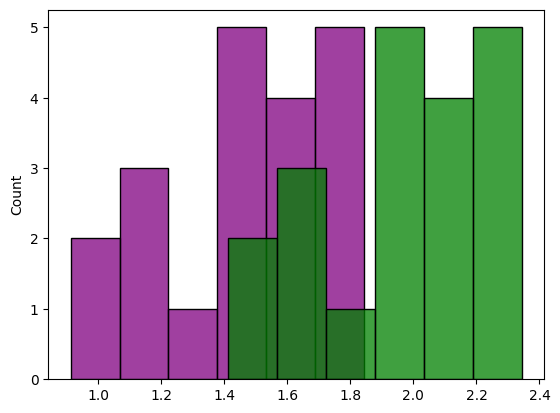

In [3]:
samples_1 = stats.norm.rvs(loc=1.5, scale=0.2, random_state=random_seed, size=20)
samples_2 = stats.norm.rvs(loc=2.0, scale=0.2, random_state=random_seed, size=20)

sns.histplot(samples_1, color="purple")
sns.histplot(samples_2, color="green")

## 1 Two Sample CI

### 1.a Calculate Mean and Std

In [4]:
mean_1 = np.sum(samples_1) / 20
mean_2 = np.sum(samples_2) / 20

# std_1 = (np.sum((samples_1 - mean_1) ** 2 ) / (20 - 1)) ** 0.5
# std_1

# std_2 = (np.sum((samples_2 - mean_2) ** 2 ) / (20 - 1)) ** 0.5
# std_2
std_1 = np.std(samples_1)
std_2 = np.std(samples_2)
print("Grp 1 Mean: %.4f" % mean_1, "Grp 1 std: %.4f" % std_1)
print("Grp 2 Mean: %.4f" % mean_2, "Grp 2 std: %.4f" % std_2)

Grp 1 Mean: 1.4850 Grp 1 std: 0.2677
Grp 2 Mean: 1.9850 Grp 2 std: 0.2677


### 1.b Compute two-sample t-statistic using ttest2

In [5]:
from scipy import stats

test_stat, pvalue =  stats.ttest_ind(samples_1, samples_2, random_state=random_seed, equal_var=False)
print("%.10f" % test_stat)
print("%.10f" % pvalue)
# print("%.10f" % test_result.df)


-5.7573461719
0.0000012253


### 1.c Compute two-sample t-statistic using GLM

### i Derive Design matrix $X$

Where $Y = X_1 B_1 + X_2 B_2 + e $

And $ X = [X_1  X_2] $


Then the dimension of the column space $C(X)$ would be $2$

In [15]:
"""Derive the design matrix"""
X = np.zeros((40, 2))
X[:20, 0] = 1
X[20:, 1] = 1
X

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [16]:
print("dim(X): ", X.shape[1])

dim(X):  2


### ii Derive general formula

$P_x = X(X^{\intercal}X)^{-1}X^{\intercal}$



In [36]:
Px = X @ np.linalg.inv(X.T @ X) @ X.T
Px

array([[0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       [0.05, 0.05, 0.05, ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05],
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05],
       [0.  , 0.  , 0.  , ..., 0.05, 0.05, 0.05]])

In [28]:
"""dim(C(X)) = rank(X) = tr(Px)"""
print("tr(Px)", np.trace(Px))

tr(Px) 2.0


### iii Determine $\hat{Y}$

In [30]:
Y = np.concatenate((samples_1, samples_2))
Y

array([1.41375869, 1.79246329, 1.44117927, 0.91265544, 1.20954837,
       1.60565228, 1.49827248, 1.20068758, 1.01593769, 1.64611097,
       1.8367004 , 1.15433193, 1.84331116, 1.36431529, 1.5683697 ,
       1.71372067, 1.84265076, 1.63305043, 1.48442323, 1.52244036,
       1.91375869, 2.29246329, 1.94117927, 1.41265544, 1.70954837,
       2.10565228, 1.99827248, 1.70068758, 1.51593769, 2.14611097,
       2.3367004 , 1.65433193, 2.34331116, 1.86431529, 2.0683697 ,
       2.21372067, 2.34265076, 2.13305043, 1.98442323, 2.02244036])

In [34]:
"""Y hat is the predicted Y values"""
"""TODO: What the fuck is Y hat"""
Y_hat = Px @ Y
Y_hat

array([1.484979, 1.484979, 1.484979, 1.484979, 1.484979, 1.484979,
       1.484979, 1.484979, 1.484979, 1.484979, 1.484979, 1.484979,
       1.484979, 1.484979, 1.484979, 1.484979, 1.484979, 1.484979,
       1.484979, 1.484979, 1.984979, 1.984979, 1.984979, 1.984979,
       1.984979, 1.984979, 1.984979, 1.984979, 1.984979, 1.984979,
       1.984979, 1.984979, 1.984979, 1.984979, 1.984979, 1.984979,
       1.984979, 1.984979, 1.984979, 1.984979])

### iv Compute $R_x$

In [50]:
Rx = np.eye(Px.shape[0]) - Px
Rx

array([[ 0.95, -0.05, -0.05, ...,  0.  ,  0.  ,  0.  ],
       [-0.05,  0.95, -0.05, ...,  0.  ,  0.  ,  0.  ],
       [-0.05, -0.05,  0.95, ...,  0.  ,  0.  ,  0.  ],
       ...,
       [ 0.  ,  0.  ,  0.  , ...,  0.95, -0.05, -0.05],
       [ 0.  ,  0.  ,  0.  , ..., -0.05,  0.95, -0.05],
       [ 0.  ,  0.  ,  0.  , ..., -0.05, -0.05,  0.95]])

In [54]:
"""Is Rx idempotent?"""
print("Rx idempotent: ", np.allclose(Rx @ Rx, Rx))
"""Is Rx symmetric?"""
print("Rx symmetric: ", np.allclose(Rx.T, Rx))


Rx idempotent:  True
Rx symmetric:  True


### v. Compute $R_x$

In [58]:
e_hat = Rx @ Y
e_hat

array([-7.12203092e-02,  3.07484287e-01, -4.37997306e-02, -5.72323563e-01,
       -2.75430631e-01,  1.20673280e-01,  1.32934766e-02, -2.84291417e-01,
       -4.69041306e-01,  1.61131971e-01,  3.51721403e-01, -3.30647072e-01,
        3.58332163e-01, -1.20663712e-01,  8.33906972e-02,  2.28741670e-01,
        3.57671764e-01,  1.48071432e-01, -5.55764912e-04,  3.74613609e-02,
       -7.12203092e-02,  3.07484287e-01, -4.37997306e-02, -5.72323563e-01,
       -2.75430631e-01,  1.20673280e-01,  1.32934766e-02, -2.84291417e-01,
       -4.69041306e-01,  1.61131971e-01,  3.51721403e-01, -3.30647072e-01,
        3.58332163e-01, -1.20663712e-01,  8.33906972e-02,  2.28741670e-01,
        3.57671764e-01,  1.48071432e-01, -5.55764912e-04,  3.74613609e-02])

In [61]:
dim_C_perpendicular = 40 - X.shape[1]
dim_C_perpendicular

38

### vi. Determine the angle between e_hat and Y_hat

In [63]:
dot_product = Y_hat @ e_hat

# Calculate the norms (magnitudes)
norm_Y_hat = np.linalg.norm(Y_hat)
norm_e_hat = np.linalg.norm(e_hat)

cos_angle = dot_product / (norm_Y_hat * norm_e_hat)

angle_degrees = np.arccos(np.clip(cos_angle, -1.0, 1.0)) * 180 / np.pi

print(f"Dot product: {dot_product}")
print(f"Cosine of angle: {cos_angle}")
print(f"Angle between Y_hat and e_hat: {angle_degrees} degrees")

# Optional: Verify orthogonality with allclose (should be very close to zero)
print(f"Are they orthogonal? {np.allclose(dot_product, 0, atol=1e-10)}")

Dot product: -1.8258366322747227e-14
Cosine of angle: -9.728273325894552e-16
Angle between Y_hat and e_hat: 90.00000000000006 degrees
Are they orthogonal? True


### vii. general formula for estimating model parameters.

In [64]:
# Step 3: Calculate the least squares estimate for β
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
XTY = X.T @ Y
beta_hat = XTX_inv @ XTY

print("Design matrix X:")
print(X[:5])  # Show first few rows

print("\nX'X:")
print(XTX)

print("\n(X'X)⁻¹:")
print(XTX_inv)

print("\nX'Y:")
print(XTY)

print("\nEstimated parameters β̂:")
print(beta_hat)

# Verify that these are indeed the group means
print("\nGroup means:")
print(f"Group 1 mean: {np.mean(Y[:20])}")
print(f"Group 2 mean: {np.mean(Y[20:])}")

Design matrix X:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]

X'X:
[[20.  0.]
 [ 0. 20.]]

(X'X)⁻¹:
[[0.05 0.  ]
 [0.   0.05]]

X'Y:
[29.69957997 39.69957997]

Estimated parameters β̂:
[1.484979 1.984979]

Group means:
Group 1 mean: 1.4849789986011837
Group 2 mean: 1.9849789986011839


### viii. Estimate the variance of the stochastic component

In [67]:
# Calculate the variance estimate σ̂²
n = X.shape[0]  # Total number of observations
dim_X = np.linalg.matrix_rank(X)  # Dimension of column space (should be 2)
sigma_squared_hat = (e_hat.T @ e_hat) / (n - dim_X)

print(f"Estimated error variance (σ̂²): {sigma_squared_hat}")

Estimated error variance (σ̂²): 0.07542152727238456


### ix. Estimate the the covariance matrix

In [68]:
# Using the σ̂² calculated in the previous step
# Calculate the covariance matrix of β̂
S_beta = sigma_squared_hat * XTX_inv

print("Covariance matrix of β̂:")
print(S_beta)

# Calculate the standard deviations of the model parameters
# The standard deviations are the square roots of the diagonal elements of S_beta
std_beta = np.sqrt(np.diag(S_beta))

print("\nStandard deviations of model parameters:")
print(f"SD of β̂₁: {std_beta[0]}")
print(f"SD of β̂₂: {std_beta[1]}")

Covariance matrix of β̂:
[[0.00377108 0.        ]
 [0.         0.00377108]]

Standard deviations of model parameters:
SD of β̂₁: 0.06140909023604916
SD of β̂₂: 0.06140909023604916


### x. Derive the appropriate contrast vector $\lambda$

In [71]:
X_0 = np.ones((20 + 20, 1))  # A column of ones
X_0

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

### xi. Use the reduced the model

In [72]:
# Create the reduced model X₀
X_0 = np.ones((20 + 20, 1))  # A column of ones

# Calculate projection matrices
X0TX0 = X_0.T @ X_0
X0TX0_inv = np.linalg.inv(X0TX0)
P_X0 = X_0 @ X0TX0_inv @ X_0.T
R_X0 = np.eye(X_0.shape[0]) - P_X0

# Calculate error sums of squares
SSE_full = (Rx @ Y).T @ (Rx @ Y)  # Error from full model
SSE_reduced = (R_X0 @ Y).T @ (R_X0 @ Y)  # Error from reduced model

# Calculate additional error due to constraint
SSE_diff = SSE_reduced - SSE_full

# Calculate degrees of freedom
df_full = n - dim_X  # n - rank(X)
df_reduced = n - np.linalg.matrix_rank(X_0)  # n - rank(X₀)
df_diff = df_reduced - df_full  # Additional constraint df

# Calculate F-statistic
F_stat = (SSE_diff / df_diff) / (SSE_full / df_full)

print(f"Error sum of squares (full model): {SSE_full}")
print(f"Error sum of squares (reduced model): {SSE_reduced}")
print(f"Additional error due to constraint: {SSE_diff}")
print(f"Degrees of freedom (full model): {df_full}")
print(f"Degrees of freedom (reduced model): {df_reduced}")
print(f"Degrees of freedom (difference): {df_diff}")
print(f"F-statistic: {F_stat}")

Error sum of squares (full model): 2.866018036350613
Error sum of squares (reduced model): 5.366018036350613
Additional error due to constraint: 2.4999999999999996
Degrees of freedom (full model): 38
Degrees of freedom (reduced model): 39
Degrees of freedom (difference): 1
F-statistic: 33.14703494363432


### xii. T-statistic

In [73]:
lambda_vec = np.array([1, -1])  # Test β₁ - β₂

# Calculate λ'β̂
lambda_beta = lambda_vec @ beta_hat

# Calculate λ'Sβ̂λ
lambda_S_lambda = lambda_vec @ S_beta @ lambda_vec

# Calculate the t-statistic
t_stat = lambda_beta / np.sqrt(lambda_S_lambda)

print(f"Contrast λ'β̂ (difference in means): {lambda_beta}")
print(f"Square root of λ'Sβ̂λ (SE of difference): {np.sqrt(lambda_S_lambda)}")
print(f"t-statistic: {t_stat}")

Contrast λ'β̂ (difference in means): -0.5
Square root of λ'Sβ̂λ (SE of difference): 0.08684556826481393
t-statistic: -5.757346171947134


### xiii. Explain the meaning of model parameters

?

### xiv. Compute the projection of the ground truth deviation e into C(X)

In [74]:
# Assuming we have the ground truth parameters
beta_true = np.array([1.5, 2.0])  # True means for groups 1 and 2

# Calculate the ground truth error term e
# (which we added when simulating the data)
e_true = Y - X @ beta_true

# Calculate the projection of e into column space C(X)
P_X = X @ XTX_inv @ X.T
e_proj_into_CX = P_X @ e_true

print("Projection of ground truth error e into C(X):")
print(e_proj_into_CX[:5])  # Show first few elements
print(f"Sum of squared projection: {e_proj_into_CX.T @ e_proj_into_CX}")

Projection of ground truth error e into C(X):
[-0.015021 -0.015021 -0.015021 -0.015021 -0.015021]
Sum of squared projection: 0.009025219320929326


xv. Compute 

In [76]:
# Calculate the projection of e into C(X)⊥
R_X = np.eye(X.shape[0]) - P_X
e_proj_into_CX_perp = R_X @ e_true

# Calculate the estimated error ê
e_hat = R_X @ Y

print("Projection of ground truth error e into C(X)⊥:")
print(e_proj_into_CX_perp[:5])  # Show first few elements

print("\nEstimated error ê:")
print(e_hat[:5])  # Show first few elements

# Compare the two
difference = e_proj_into_CX_perp - e_hat
print("\nDifference between e projected into C(X)⊥ and ê:")
print(difference[:5])
print(f"Sum of squared differences: {difference.T @ difference}")

Projection of ground truth error e into C(X)⊥:
[-0.07122031  0.30748429 -0.04379973 -0.57232356 -0.27543063]

Estimated error ê:
[-0.07122031  0.30748429 -0.04379973 -0.57232356 -0.27543063]

Difference between e projected into C(X)⊥ and ê:
[3.60822483e-16 1.11022302e-16 2.35922393e-16 3.33066907e-16
 3.33066907e-16]
Sum of squared differences: 3.8679233482168765e-30


## D. Compute t-statistic with a different model